# Predicción de Attrition de Empleados
### Prueba Técnica — f1rst Uruguay

Este notebook cubre el flujo completo del desafío:
1. Análisis Exploratorio de Datos (EDA)
2. Feature Engineering
3. Modelado y Evaluación


# Exploratory Data Analysis
## Attrition Dataset

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import pickle
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
with open('../data/attrition_dataset.pkl', 'rb') as f:
    df = pd.read_pickle('../data/attrition_dataset.pkl')

df = df.reset_index(drop=True)
print(f'Shape: {df.shape}')
df.head()

Shape: (1426, 31)


,hrs,absences,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
1,7.315971,13,2.0,4,3.0,2.0,4.0,31.0,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,NaN,0.0,Y,23,8,1,6.0,3,5,1,4
6,6.450877,17,3.0,4,1.0,3.0,1.0,28.0,Yes,Travel_Rarely,Research & Development,11,2,Medical,1,7,Male,2,Sales Executive,Single,58130.0,2.0,Y,20,8,1,5.0,2,0,0,0
13,8.871421,14,2.0,3,1.0,2.0,2.0,47.0,Yes,Non-Travel,Research & Development,1,1,Medical,1,14,Male,1,Research Scientist,Married,57620.0,1.0,Y,11,8,2,10.0,4,10,9,9
28,10.713066,6,2.0,3,4.0,3.0,1.0,44.0,Yes,Travel_Frequently,Research & Development,1,2,Medical,1,29,Male,2,Research Scientist,Divorced,103330.0,3.0,Y,14,8,1,19.0,2,1,0,0
30,9.662808,11,2.0,3,1.0,2.0,3.0,26.0,Yes,Travel_Rarely,Research & Development,4,3,Medical,1,31,Male,3,Research Scientist,Divorced,68540.0,2.0,Y,11,8,0,5.0,5,3,0,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1426 entries, 1 to 3786
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   hrs                      1426 non-null   float64
 1   absences                 1426 non-null   int64  
 2   JobInvolvement           1279 non-null   float64
 3   PerformanceRating        1426 non-null   int64  
 4   EnvironmentSatisfaction  1418 non-null   float64
 5   JobSatisfaction          1267 non-null   float64
 6   WorkLifeBalance          1419 non-null   float64
 7   Age                      1292 non-null   float64
 8   Attrition                1426 non-null   object 
 9   BusinessTravel           1426 non-null   object 
 10  Department               1426 non-null   object 
 11  DistanceFromHome         1426 non-null   int64  
 12  Education                1426 non-null   int64  
 13  EducationField           1426 non-null   object 
 14  EmployeeCount            1426

In [4]:
df.describe()

,hrs,absences,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
count,1426.000000,1426.000000,1279.000000,1426.000000,1418.000000,1267.000000,1419.000000,1292.000000,1426.000000,1426.000000,1426.0,1426.000000,1426.000000,1293.000000,1420.000000,1426.000000,1426.0,1426.000000,1424.000000,1426.000000,1426.000000,1426.000000,1426.000000
mean,7.622009,12.596774,2.722439,3.156381,2.672073,2.658248,2.711769,35.427245,9.367461,2.908135,1.0,2187.990884,2.096774,63568.437742,2.805634,15.256662,8.0,0.767882,10.048455,2.742637,6.284011,2.013324,3.615708
std,1.439585,5.506943,0.756022,0.363344,1.131606,1.092492,0.758178,9.330001,8.016363,1.009070,0.0,1279.551636,1.120352,46313.904737,2.557631,3.701689,0.0,0.832738,7.623228,1.266726,6.149938,3.125307,3.507326
min,5.465741,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000,1.0,2.000000,1.000000,10090.000000,0.000000,11.000000,8.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.438629,8.000000,2.000000,3.000000,2.000000,2.000000,2.000000,29.000000,2.000000,2.000000,1.0,1069.750000,1.000000,28530.000000,1.000000,12.000000,8.0,0.000000,5.000000,2.000000,2.000000,0.000000,0.000000
50%,7.322339,13.000000,3.000000,3.000000,3.000000,3.000000,3.000000,34.000000,7.000000,3.000000,1.0,2125.000000,2.000000,48210.000000,2.000000,14.000000,8.0,1.000000,9.000000,3.000000,5.000000,1.000000,2.000000
75%,8.660602,17.000000,3.000000,3.000000,4.000000,4.000000,3.000000,41.000000,15.000000,4.000000,1.0,3335.000000,3.000000,76440.000000,4.000000,18.000000,8.0,1.000000,13.000000,3.000000,9.000000,2.000000,7.000000
max,10.937261,23.000000,4.000000,4.000000,4.000000,4.000000,4.000000,60.000000,29.000000,5.000000,1.0,4409.000000,5.000000,198590.000000,9.000000,25.000000,8.0,3.000000,40.000000,6.000000,40.000000,15.000000,17.000000


In [5]:
df.isnull().sum()[df.isnull().sum() > 0]

JobInvolvement             147
EnvironmentSatisfaction      8
JobSatisfaction            159
WorkLifeBalance              7
Age                        134
MonthlyIncome              133
NumCompaniesWorked           6
TotalWorkingYears            2
dtype: int64

## 1. Variable Objetivo — Attrition

Distribución de Attrition:
           count     %
Attrition             
No           715  50.1
Yes          711  49.9


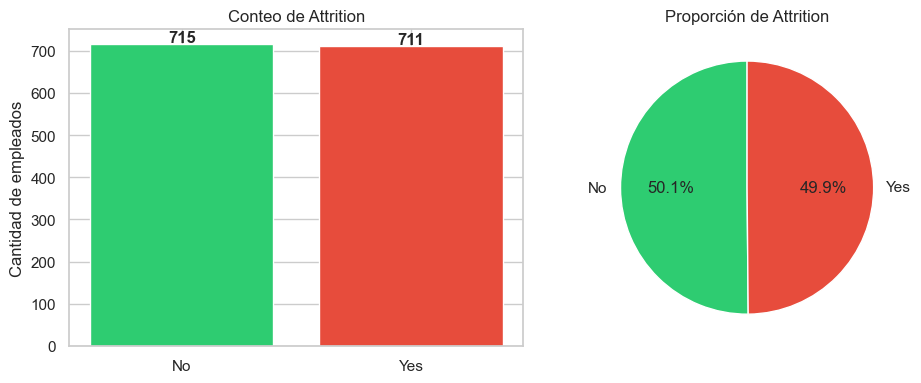

In [6]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print("Distribución de Attrition:")
print(pd.DataFrame({'count': attrition_counts, '%': attrition_pct.round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(attrition_counts.index, attrition_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Conteo de Attrition')
axes[0].set_ylabel('Cantidad de empleados')
for i, (label, val) in enumerate(attrition_counts.items()):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

axes[1].pie(attrition_counts.values, labels=attrition_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de Attrition')

plt.tight_layout()
plt.show()

## 2. Variables con Baja o Nula Variabilidad

Se analizan las variables que podrían no aportar información predictiva.

Valores únicos por variable:

EmployeeCount                 1
Over18                        1
StandardHours                 1
PerformanceRating             2
Attrition                     2
Gender                        2
BusinessTravel                3
Department                    3
MaritalStatus                 3
JobInvolvement                4
JobSatisfaction               4
StockOptionLevel              4
WorkLifeBalance               4
EnvironmentSatisfaction       4
JobLevel                      5
Education                     5
EducationField                6
TrainingTimesLastYear         7
JobRole                       9
NumCompaniesWorked           10
PercentSalaryHike            15
YearsSinceLastPromotion      16
YearsWithCurrManager         18
absences                     23
DistanceFromHome             29
YearsAtCompany               35
TotalWorkingYears            40
Age                          43
MonthlyIncome               684
hrs                        1350
EmployeeID

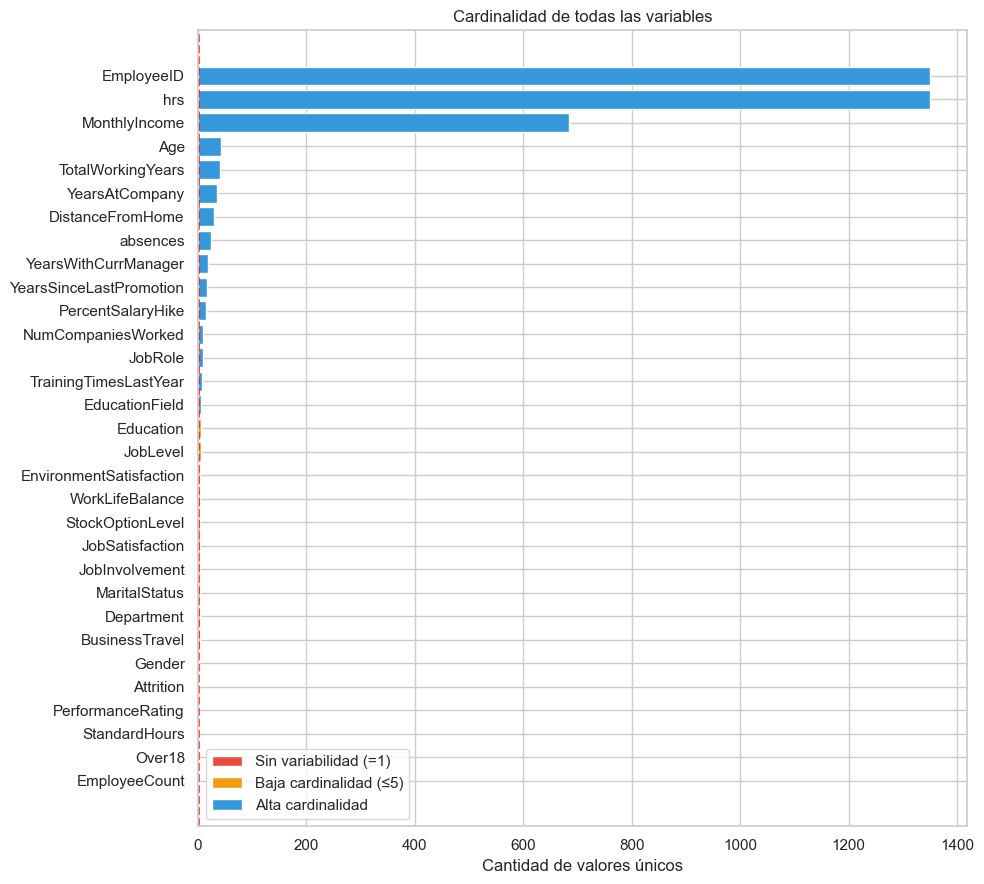


Variables con un único valor: ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount: [1]
  Over18: ['Y']
  StandardHours: [8]


In [7]:
unique_counts = df.nunique().sort_values()
print("Valores únicos por variable:\n")
print(unique_counts.to_string())

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#e74c3c' if v == 1 else '#f39c12' if v <= 5 else '#3498db' for v in unique_counts.values]
ax.barh(unique_counts.index, unique_counts.values, color=colors)
ax.set_xlabel('Cantidad de valores únicos')
ax.set_title('Cardinalidad de todas las variables')
ax.axvline(x=1, color='red', linestyle='--', alpha=0.7, label='Sin variabilidad (n=1)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Sin variabilidad (=1)'),
                   Patch(facecolor='#f39c12', label='Baja cardinalidad (≤5)'),
                   Patch(facecolor='#3498db', label='Alta cardinalidad')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

# Distribución de las variables sin variabilidad
zero_var = unique_counts[unique_counts == 1].index.tolist()
print(f"\nVariables con un único valor: {zero_var}")
for col in zero_var:
    print(f"  {col}: {df[col].unique()}")

## 3. Variables Numéricas

Variables numéricas (23): ['hrs', 'absences', 'JobInvolvement', 'PerformanceRating', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'Age', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeID', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


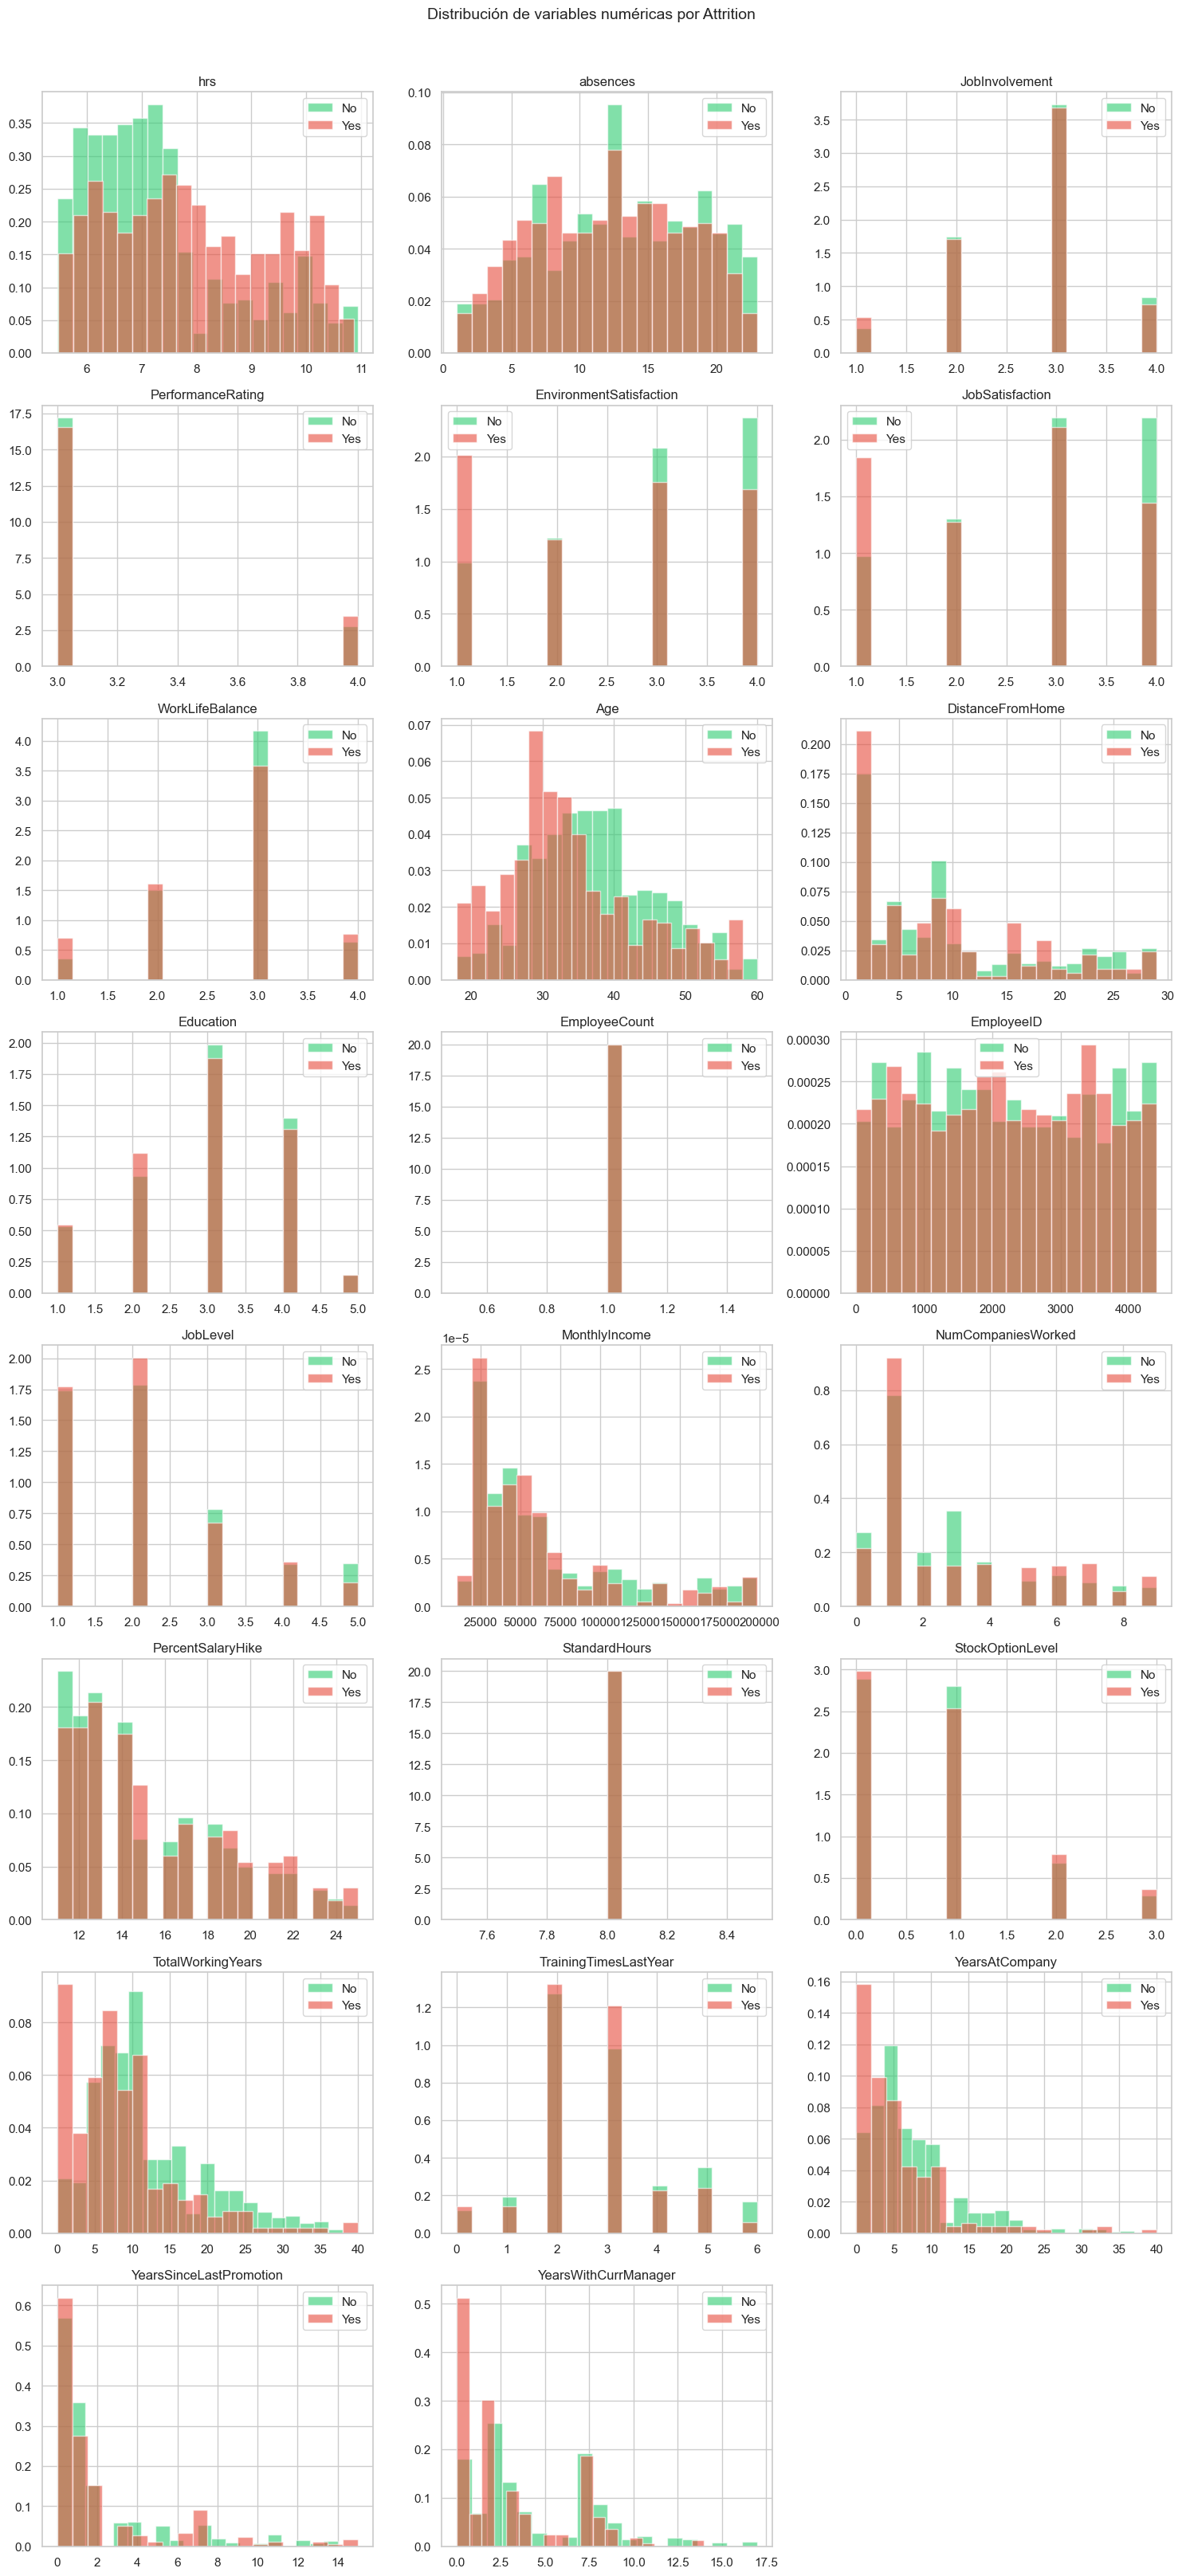

In [8]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Variables numéricas ({len(num_cols)}): {num_cols}')

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
        data = df[df['Attrition'] == label][col].dropna()
        axes[i].hist(data, bins=20, alpha=0.6, label=label, color=color, density=True)
    axes[i].set_title(col)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas por Attrition', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Variables Categóricas

Variables categóricas (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18']


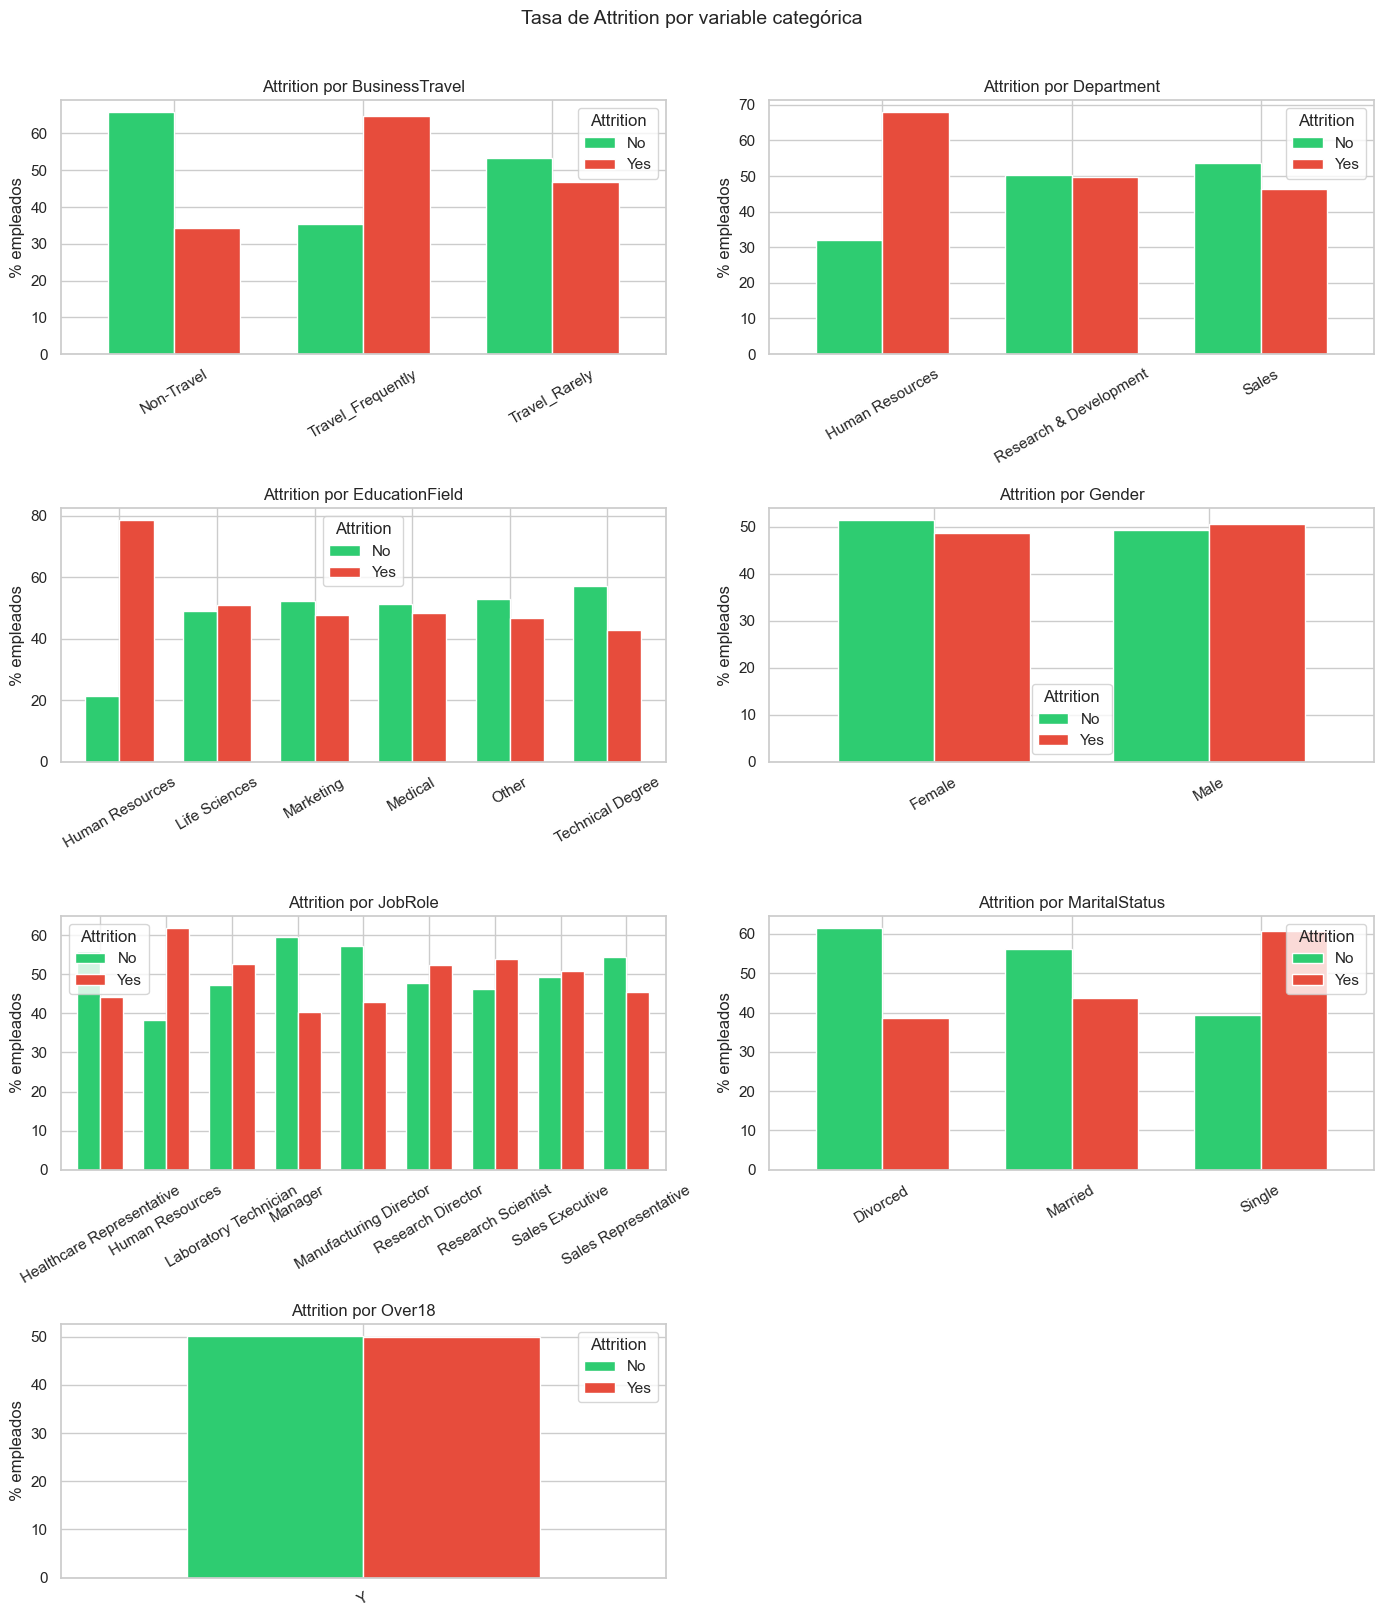

In [9]:
cat_cols = df.select_dtypes(include='object').columns.drop('Attrition').tolist()
print(f'Variables categóricas ({len(cat_cols)}): {cat_cols}')

n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby(col)['Attrition'].value_counts(normalize=True).unstack().fillna(0) * 100
    ct[['No', 'Yes']].plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
                            edgecolor='white', width=0.7)
    axes[i].set_title(f'Attrition por {col}')
    axes[i].set_ylabel('% empleados')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Attrition')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Tasa de Attrition por variable categórica', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlación entre Variables Numéricas

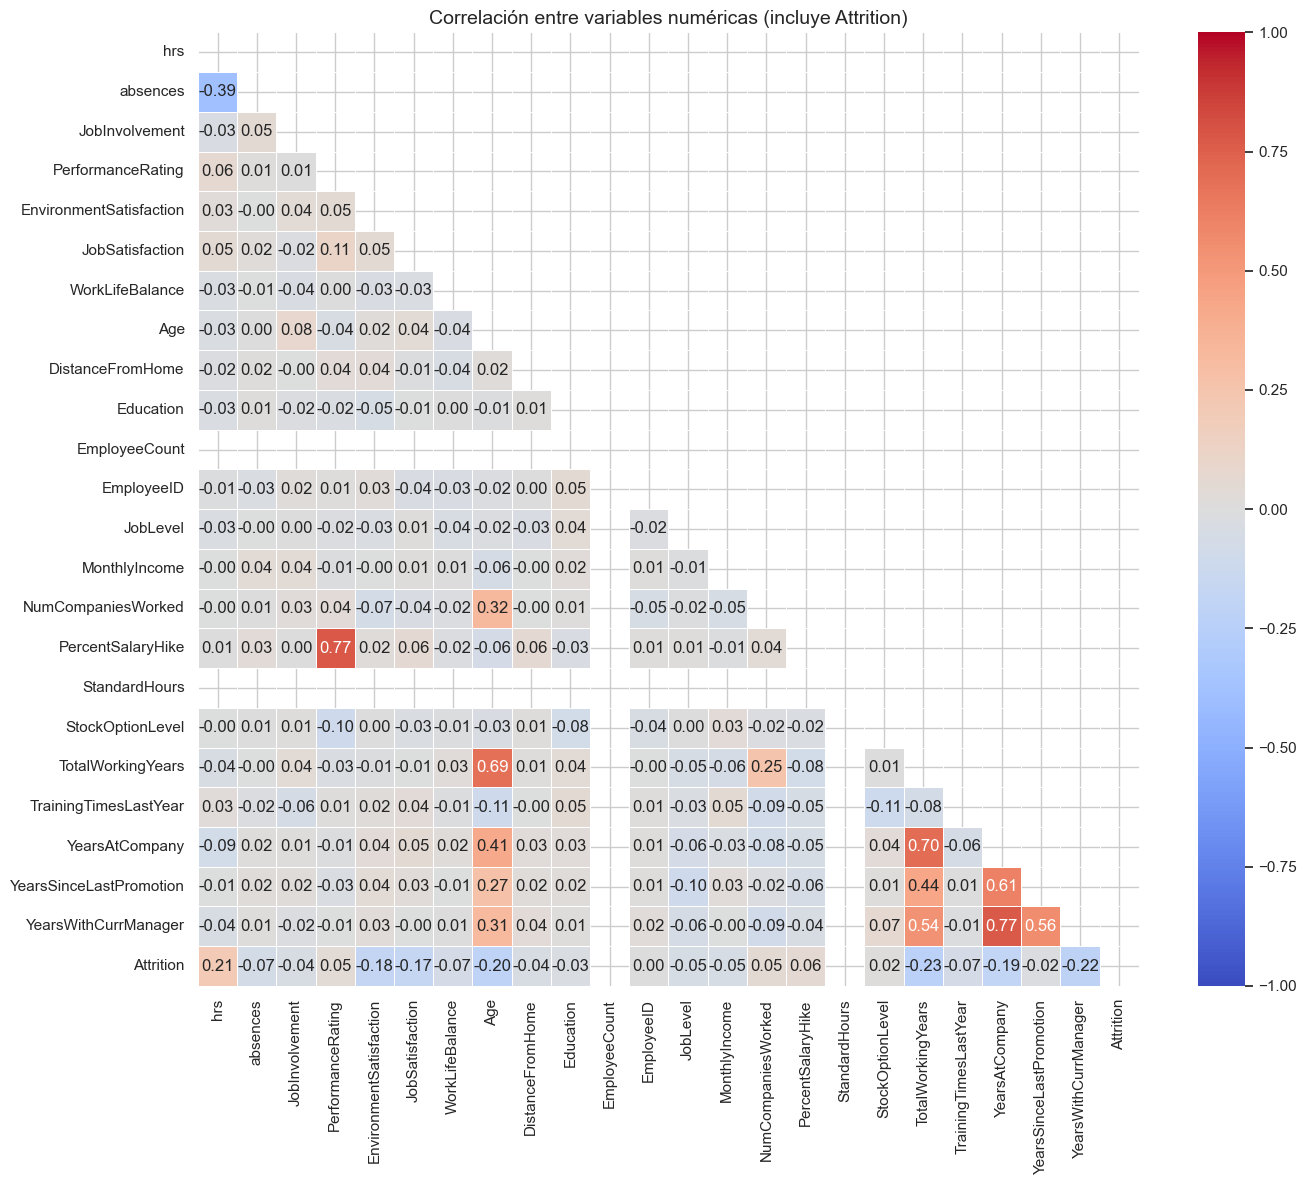

In [10]:
df_corr = df[num_cols].copy()
df_corr['Attrition'] = (df['Attrition'] == 'Yes').astype(int)

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlación entre variables numéricas (incluye Attrition)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Valores Faltantes

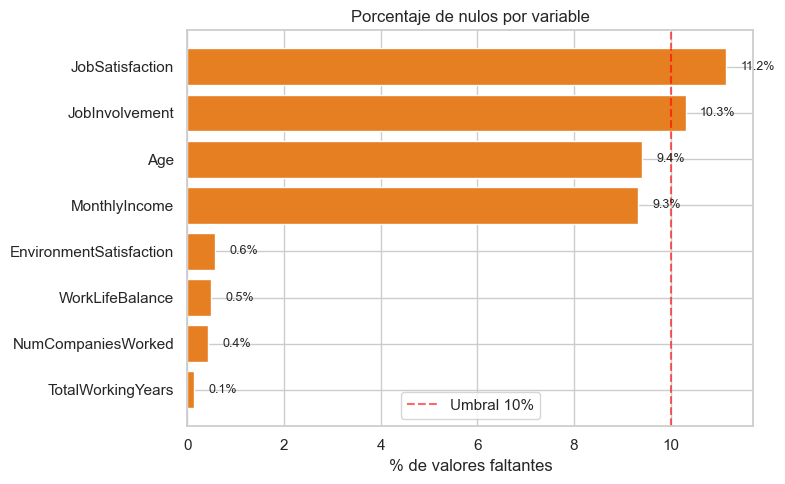

In [11]:
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(missing.index, missing.values, color='#e67e22')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Porcentaje de nulos por variable')
ax.axvline(x=10, color='red', linestyle='--', alpha=0.6, label='Umbral 10%')
ax.legend()
for bar, val in zip(bars, missing.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Outliers en Variables Numéricas

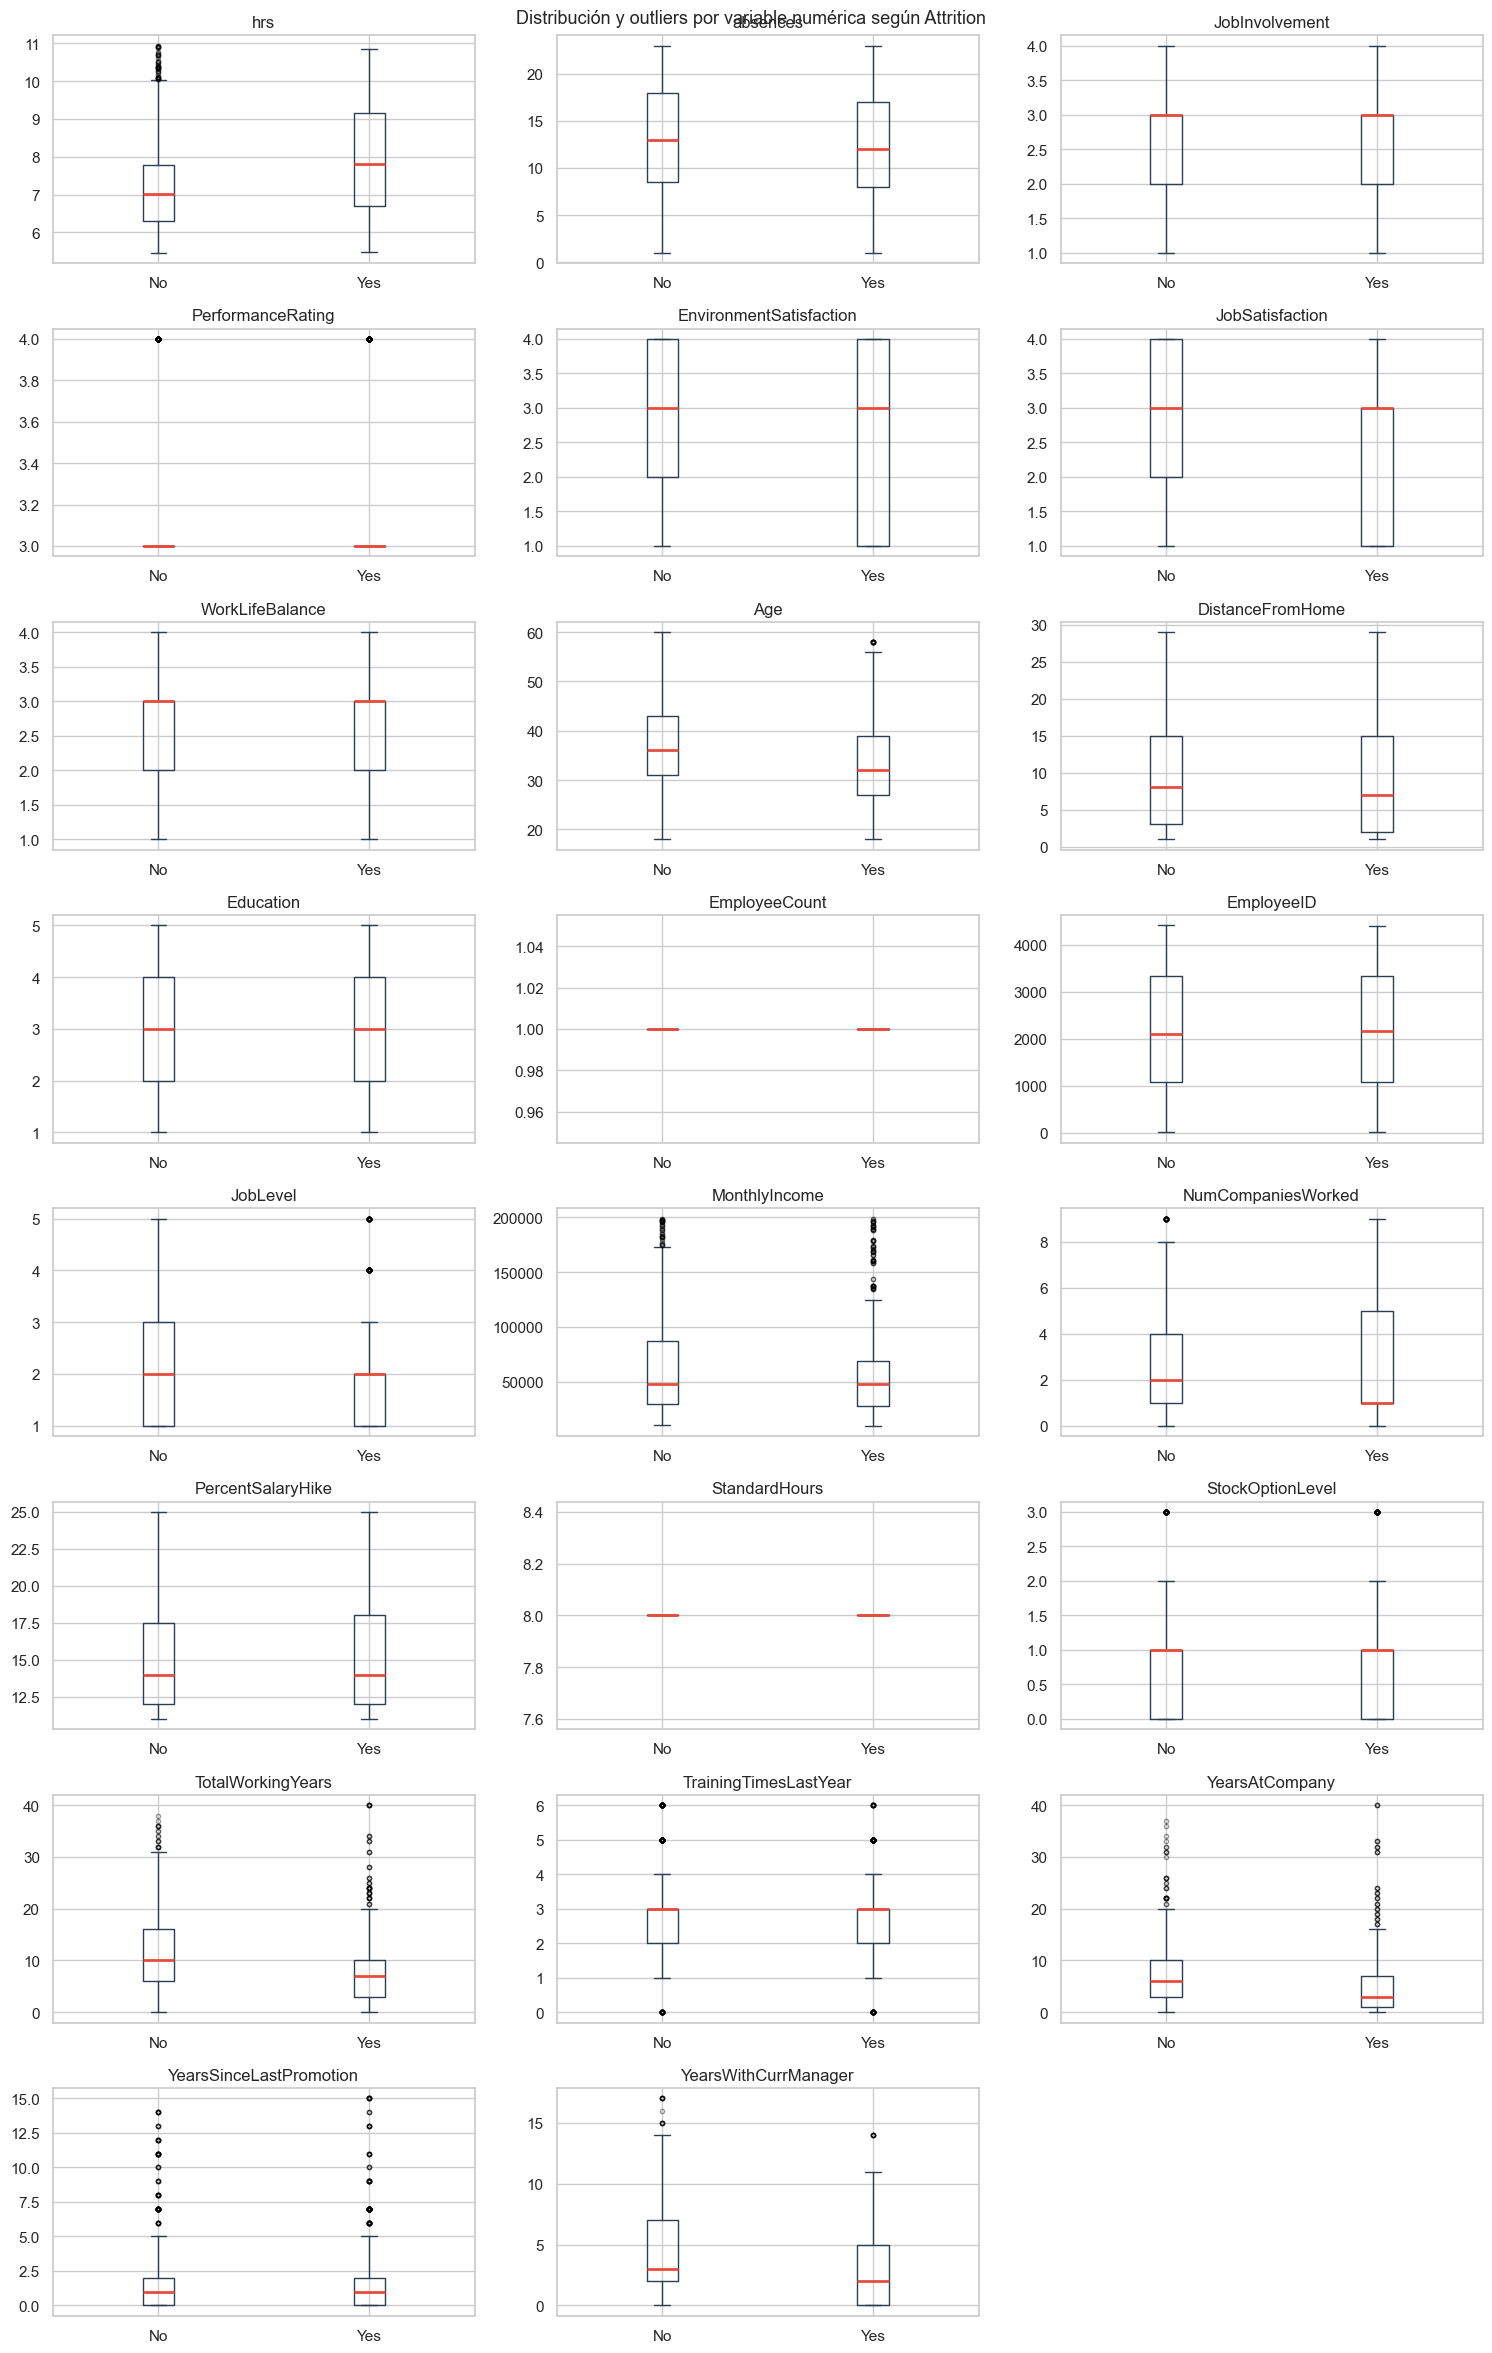

In [12]:
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Attrition', ax=axes[i],
               boxprops=dict(color='#2c3e50'),
               medianprops=dict(color='#e74c3c', linewidth=2),
               whiskerprops=dict(color='#2c3e50'),
               capprops=dict(color='#2c3e50'),
               flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#e74c3c'))
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución y outliers por variable numérica según Attrition', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Correlación con el Target

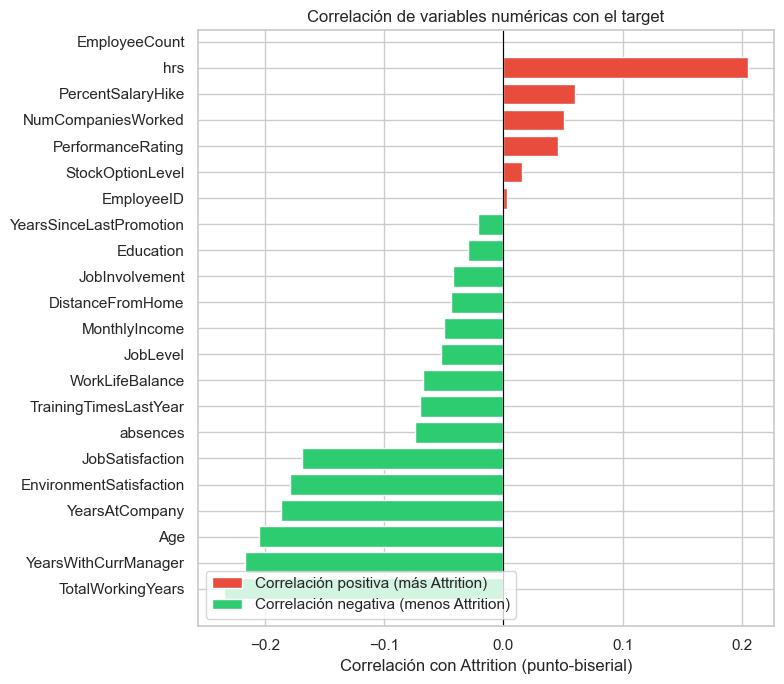

Top 5 variables con mayor correlación absoluta con Attrition:
TotalWorkingYears       0.234317
YearsWithCurrManager    0.217122
hrs                     0.205103
Age                     0.204864
YearsAtCompany          0.187056


In [13]:
target = (df['Attrition'] == 'Yes').astype(int)
corr_target = df[num_cols].corrwith(target).sort_values()

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_target.values]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(corr_target.index, corr_target.values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación con Attrition (punto-biserial)')
ax.set_title('Correlación de variables numéricas con el target')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Correlación positiva (más Attrition)'),
                   Patch(facecolor='#2ecc71', label='Correlación negativa (menos Attrition)')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

print("Top 5 variables con mayor correlación absoluta con Attrition:")
print(corr_target.abs().sort_values(ascending=False).head(5).to_string())

## 9. Distribución de las Variables más Correlacionadas con el Target


Top 6 variables por correlación absoluta con Attrition: ['TotalWorkingYears', 'YearsWithCurrManager', 'hrs', 'Age', 'YearsAtCompany', 'EnvironmentSatisfaction']


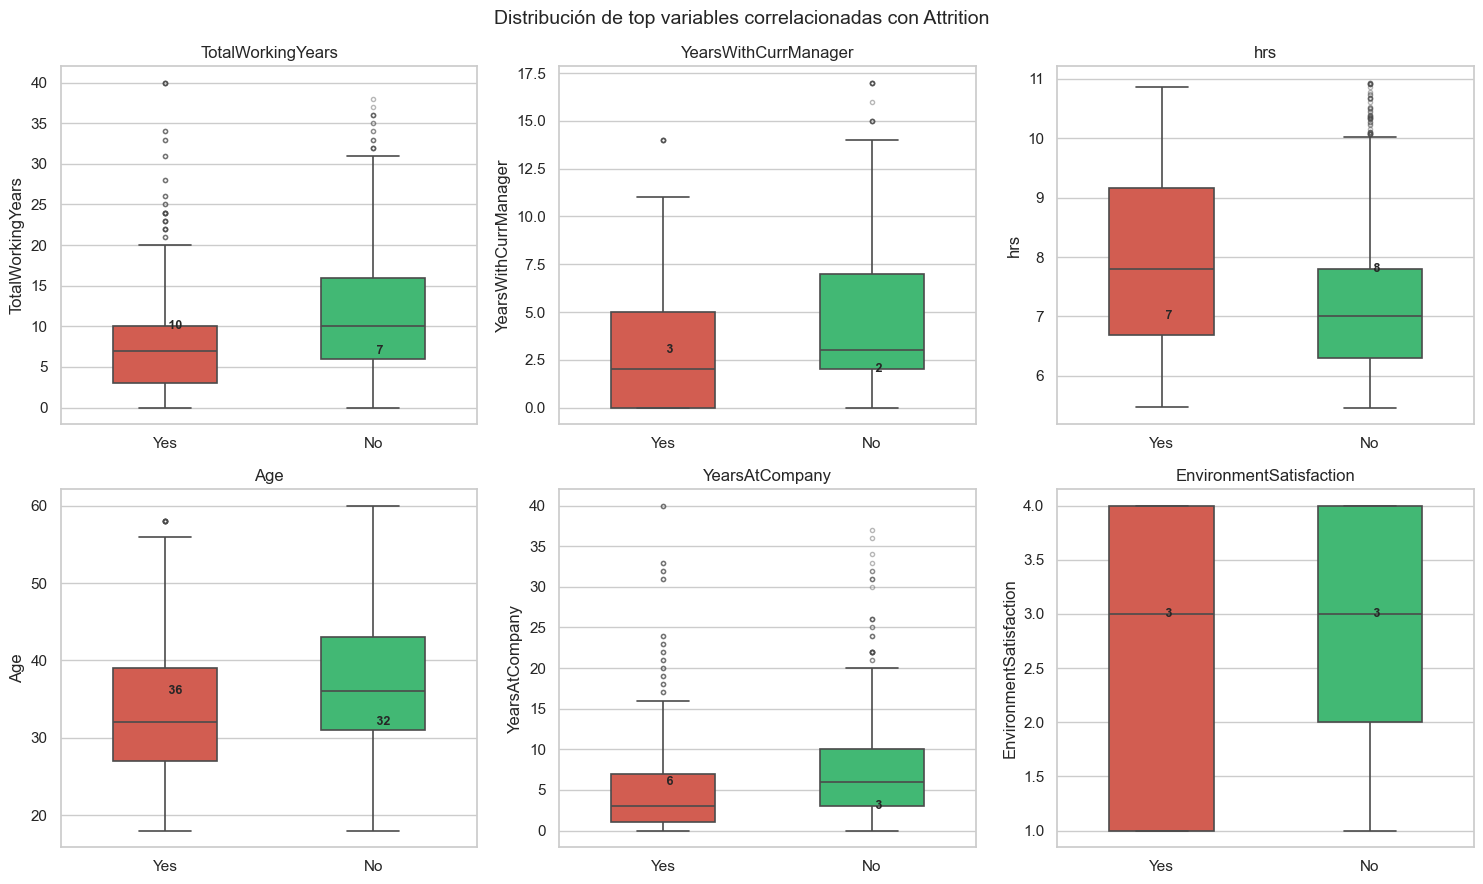

In [14]:
top_vars = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()
print(f"Top 6 variables por correlación absoluta con Attrition: {top_vars}")

df_plot = df.reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
palette = {'No': '#2ecc71', 'Yes': '#e74c3c'}

for i, col in enumerate(top_vars):
    sns.boxplot(data=df_plot, x='Attrition', y=col, ax=axes[i],
                palette=palette, width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    axes[i].set_title(col)
    axes[i].set_xlabel('')

    medians = df_plot.groupby('Attrition')[col].median()
    for j, (label, med) in enumerate(medians.items()):
        axes[i].text(j, med, f' {med:.0f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Distribución de top variables correlacionadas con Attrition', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Conclusiones del EDA

### Target
- Dataset **perfectamente balanceado** (50.1% No / 49.9% Yes). No se requieren técnicas de balanceo de clases.

### Variables a descartar en preprocesamiento
- `EmployeeCount`, `StandardHours`, `Over18`: sin variabilidad, valor constante en todos los registros.
- `EmployeeID`: identificador único sin valor predictivo.

### Valores faltantes
- 8 variables presentan nulos. Las más afectadas: `JobSatisfaction` (~11%), `JobInvolvement` (~10%), `Age` (~9%), `MonthlyIncome` (~9%).
- Ninguna supera el 15%, por lo que la imputación es viable sin descartar columnas.
- Una alternativa más sofisticada sería imputación por **KNN**: buscar registros similares y asignarle el valor del vecino más cercano, preservando mejor la estructura del dato. Sin embargo, dado el tiempo y la complejidad que requiere, **se optará por imputación con la mediana**, que es robusta ante outliers y suficiente para este contexto.

### Variables más relevantes para el modelo
Según la correlación punto-biserial con Attrition:
- **Correlación negativa** (más valor → menos Attrition): `TotalWorkingYears`, `YearsWithCurrManager`, `Age`, `YearsAtCompany` — empleados con más experiencia y antigüedad tienden a quedarse.
- **Correlación positiva** (más valor → más Attrition): `hrs` — empleados con más horas trabajadas muestran mayor rotación.
- Las variables de **satisfacción** (`JobSatisfaction`, `EnvironmentSatisfaction`, `WorkLifeBalance`) también muestran correlación negativa relevante.


---
# Feature Engineering
---

## 1. Indice de Satisfaccion General

El dataset tiene 4 variables de satisfaccion: `JobSatisfaction`, `EnvironmentSatisfaction`, `WorkLifeBalance` e `JobInvolvement`. Cada una captura una dimension del bienestar del empleado. Se propone crear un **indice compuesto** como promedio de las cuatro, para tener una senal mas robusta y reducir el ruido de cada variable individual.

si todas correlacionan negativamente con Attrition, su promedio deberia amplificar esa señal.

Correlacion individual con Attrition:
  JobSatisfaction: -0.169
  EnvironmentSatisfaction: -0.179
  WorkLifeBalance: -0.067
  JobInvolvement: -0.043

Correlacion de satisfaction_index con Attrition: -0.237


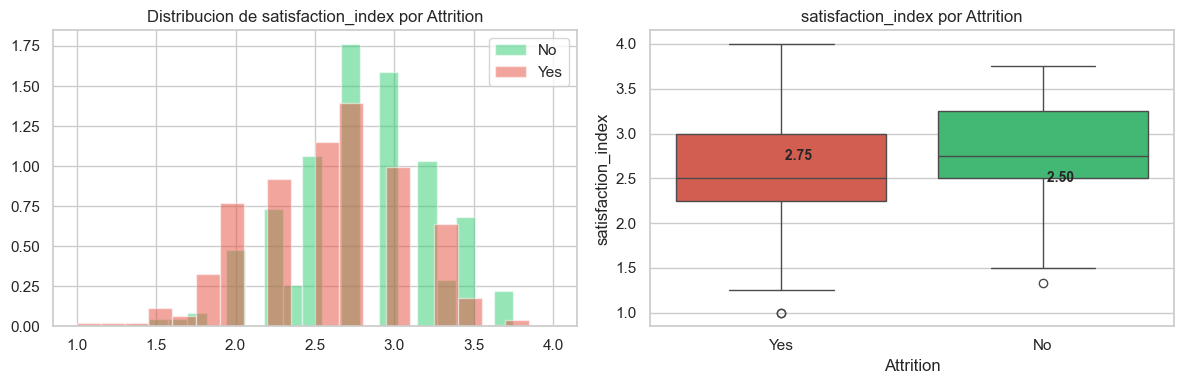

In [3]:
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

print('Correlacion individual con Attrition:')
for col in sat_cols:
    corr = df[col].corr(target)
    print(f'  {col}: {corr:.3f}')

df['satisfaction_index'] = df[sat_cols].mean(axis=1)
corr_new = df['satisfaction_index'].corr(target)
print(f'\nCorrelacion de satisfaction_index con Attrition: {corr_new:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    data = df[df['Attrition'] == label]['satisfaction_index'].dropna()
    axes[0].hist(data, bins=20, alpha=0.5, label=label, color=color, density=True)
axes[0].set_title('Distribucion de satisfaction_index por Attrition')
axes[0].legend()

sns.boxplot(data=df, x='Attrition', y='satisfaction_index', ax=axes[1],
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
axes[1].set_title('satisfaction_index por Attrition')
medians = df.groupby('Attrition')['satisfaction_index'].median()
for j, (label, med) in enumerate(medians.items()):
    axes[1].text(j, med, f' {med:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Ratio de Antiguedad en la Empresa

`YearsAtCompany` y `TotalWorkingYears` por separado no capturan la **lealtad relativa** del empleado. Un empleado con 5 anos en la empresa y 5 anos de experiencia total es muy diferente a uno con 5 anos en la empresa y 20 de experiencia total.

Se crea: `company_tenure_ratio = YearsAtCompany / (TotalWorkingYears + 1)`

Un valor cercano a 1 indica que el empleado ha pasado casi toda su carrera en esta empresa. Un valor bajo indica mayor movilidad laboral.

Correlacion YearsAtCompany con Attrition:       -0.187
Correlacion TotalWorkingYears con Attrition:    -0.234
Correlacion company_tenure_ratio con Attrition: -0.128


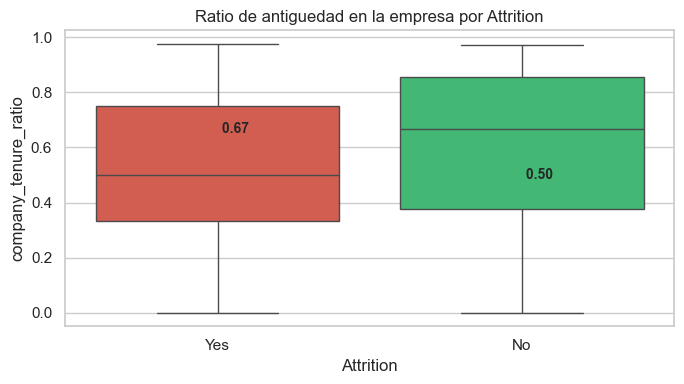

In [4]:
df['company_tenure_ratio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)

corr = df['company_tenure_ratio'].corr(target)
corr_years = df['YearsAtCompany'].corr(target)
corr_total = df['TotalWorkingYears'].corr(target)

print(f'Correlacion YearsAtCompany con Attrition:       {corr_years:.3f}')
print(f'Correlacion TotalWorkingYears con Attrition:    {corr_total:.3f}')
print(f'Correlacion company_tenure_ratio con Attrition: {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Attrition', y='company_tenure_ratio', ax=ax,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
ax.set_title('Ratio de antiguedad en la empresa por Attrition')
medians = df.groupby('Attrition')['company_tenure_ratio'].median()
for j, (label, med) in enumerate(medians.items()):
    ax.text(j, med, f' {med:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Estancamiento en Promociones

`YearsSinceLastPromotion` en valores absolutos no es tan informativo: 3 anos sin promocion siendo nuevo en la empresa es normal, pero 3 anos sin promocion con 15 anos de antiguedad puede indicar frustracion.

Se crea: `promotion_stagnation = YearsSinceLastPromotion / (YearsAtCompany + 1)`

Un valor alto indica que el empleado lleva mucho tiempo sin ascender en relacion a su tiempo en la empresa.

Correlacion YearsSinceLastPromotion con Attrition: -0.022
Correlacion promotion_stagnation con Attrition:    0.036


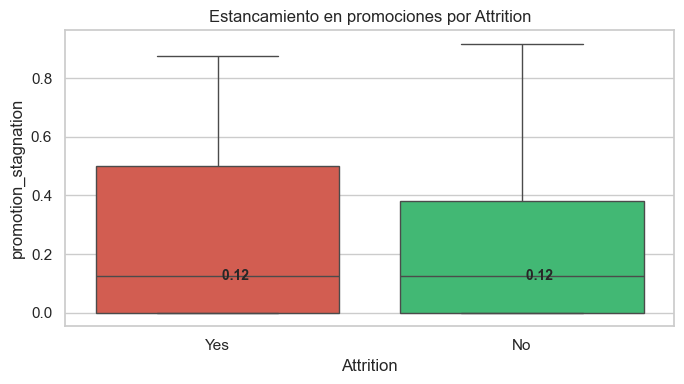

In [5]:
df['promotion_stagnation'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)

corr = df['promotion_stagnation'].corr(target)
corr_orig = df['YearsSinceLastPromotion'].corr(target)

print(f'Correlacion YearsSinceLastPromotion con Attrition: {corr_orig:.3f}')
print(f'Correlacion promotion_stagnation con Attrition:    {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Attrition', y='promotion_stagnation', ax=ax,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
ax.set_title('Estancamiento en promociones por Attrition')
medians = df.groupby('Attrition')['promotion_stagnation'].median()
for j, (label, med) in enumerate(medians.items()):
    ax.text(j, med, f' {med:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Ingreso Relativo al Nivel del Puesto

Un empleado puede estar bien o mal remunerado **para su nivel jerarquico**. `MonthlyIncome` por si solo no captura si el sueldo es justo en relacion al `JobLevel`.

Se crea: `income_vs_level = (MonthlyIncome - media_del_nivel) / media_del_nivel`

Un valor negativo indica que el empleado gana menos que el promedio de su nivel, lo que podria motivar su salida.

Correlacion MonthlyIncome con Attrition:   -0.050
Correlacion income_vs_level con Attrition: -0.060

Ingreso promedio por JobLevel:
JobLevel
1    60532.0
2    69206.0
3    58011.0
4    65690.0
5    55691.0


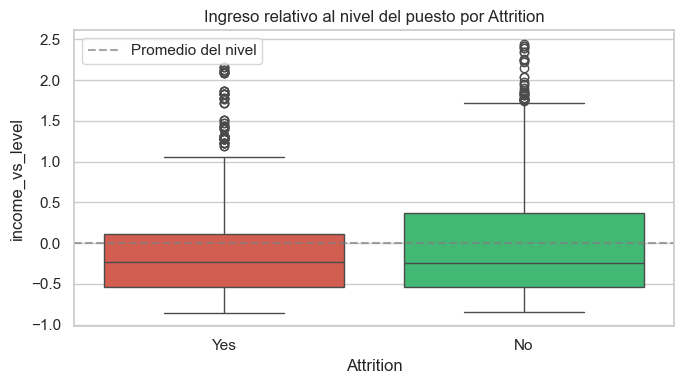

In [6]:
avg_income_by_level = df.groupby('JobLevel')['MonthlyIncome'].transform('mean')
df['income_vs_level'] = (df['MonthlyIncome'] - avg_income_by_level) / avg_income_by_level

corr = df['income_vs_level'].corr(target)
corr_orig = df['MonthlyIncome'].corr(target)

print(f'Correlacion MonthlyIncome con Attrition:   {corr_orig:.3f}')
print(f'Correlacion income_vs_level con Attrition: {corr:.3f}')

print('\nIngreso promedio por JobLevel:')
print(df.groupby('JobLevel')['MonthlyIncome'].mean().round(0).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Attrition', y='income_vs_level', ax=ax,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
ax.axhline(0, color='gray', linestyle='--', alpha=0.7, label='Promedio del nivel')
ax.set_title('Ingreso relativo al nivel del puesto por Attrition')
ax.legend()
plt.tight_layout()
plt.show()

---

## 6. Estabilidad con el Manager

`YearsWithCurrManager` tiene correlación -0.22 con Attrition, pero en términos absolutos no dice mucho. Un empleado con 3 años con el mismo manager que lleva 3 años en la empresa (100% del tiempo) es muy diferente a uno con 3 años con el mismo manager pero 15 años en la empresa (20% del tiempo).

Se crea: `manager_loyalty_ratio = YearsWithCurrManager / (YearsAtCompany + 1)`

Un valor alto indica que el empleado ha pasado la mayor parte de su tiempo en la empresa bajo el mismo manager, lo que sugiere una relación estable.

Correlacion YearsWithCurrManager con Attrition: -0.217
Correlacion YearsAtCompany con Attrition:       -0.187
Correlacion manager_loyalty_ratio con Attrition: -0.188


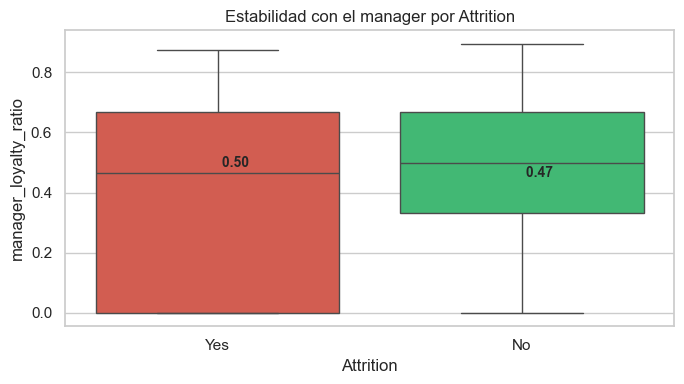

In [7]:
df['manager_loyalty_ratio'] = df['YearsWithCurrManager'] / (df['YearsAtCompany'] + 1)

corr = df['manager_loyalty_ratio'].corr(target)
corr_mgr = df['YearsWithCurrManager'].corr(target)
corr_yac = df['YearsAtCompany'].corr(target)

print(f'Correlacion YearsWithCurrManager con Attrition: {corr_mgr:.3f}')
print(f'Correlacion YearsAtCompany con Attrition:       {corr_yac:.3f}')
print(f'Correlacion manager_loyalty_ratio con Attrition: {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Attrition', y='manager_loyalty_ratio', ax=ax,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
ax.set_title('Estabilidad con el manager por Attrition')
medians = df.groupby('Attrition')['manager_loyalty_ratio'].median()
for j, (label, med) in enumerate(medians.items()):
    ax.text(j, med, f' {med:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Densidad de Experiencia

`TotalWorkingYears` (-0.25) y `Age` (-0.22) son las dos variables más correlacionadas con Attrition individualmente. Combinarlas en un ratio captura la **madurez profesional relativa**: cuánto de la vida adulta del empleado ha sido experiencia laboral.

Se crea: `experience_density = TotalWorkingYears / (Age - 17)`

Un valor cercano a 1 indica que empezó a trabajar muy joven y lleva mucho tiempo en el mercado laboral. Empleados con mayor densidad de experiencia tienden a ser más estables.

Correlacion TotalWorkingYears con Attrition: -0.234
Correlacion Age con Attrition:               -0.205
Correlacion experience_density con Attrition: -0.173


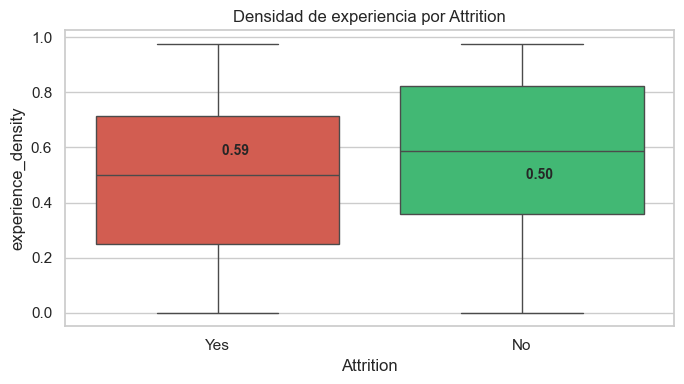

In [8]:
df['experience_density'] = df['TotalWorkingYears'] / (df['Age'] - 17)

corr = df['experience_density'].corr(target)
corr_twy = df['TotalWorkingYears'].corr(target)
corr_age = df['Age'].corr(target)

print(f'Correlacion TotalWorkingYears con Attrition: {corr_twy:.3f}')
print(f'Correlacion Age con Attrition:               {corr_age:.3f}')
print(f'Correlacion experience_density con Attrition: {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Attrition', y='experience_density', ax=ax,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
ax.set_title('Densidad de experiencia por Attrition')
medians = df.groupby('Attrition')['experience_density'].median()
for j, (label, med) in enumerate(medians.items()):
    ax.text(j, med, f' {med:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Presión de Sobrecarga Laboral

`hrs` tiene correlación +0.21 (más horas → más Attrition) y `WorkLifeBalance` tiene -0.12 (mejor balance → menos Attrition). Juntas capturan el concepto de **burnout**: muchas horas con mal balance de vida.

Se crea: `overwork_pressure = hrs / (WorkLifeBalance + 0.5)`

Un valor alto indica empleados que trabajan mucho y tienen mal balance, perfil de riesgo de desgaste y salida.

Correlacion hrs con Attrition:              0.205
Correlacion WorkLifeBalance con Attrition:  -0.067
Correlacion overwork_pressure con Attrition: 0.179


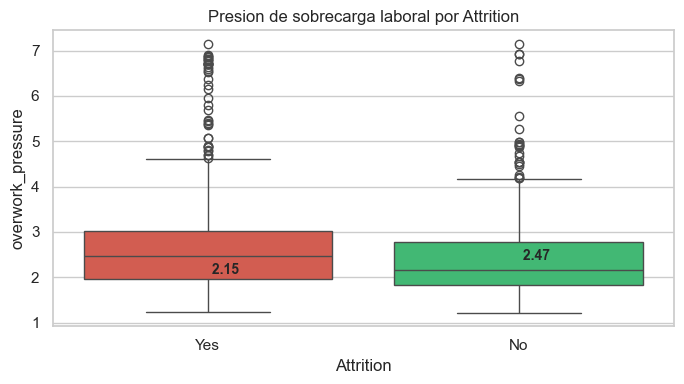

In [9]:
df['overwork_pressure'] = df['hrs'] / (df['WorkLifeBalance'] + 0.5)

corr = df['overwork_pressure'].corr(target)
corr_hrs = df['hrs'].corr(target)
corr_wlb = df['WorkLifeBalance'].corr(target)

print(f'Correlacion hrs con Attrition:              {corr_hrs:.3f}')
print(f'Correlacion WorkLifeBalance con Attrition:  {corr_wlb:.3f}')
print(f'Correlacion overwork_pressure con Attrition: {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Attrition', y='overwork_pressure', ax=ax,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
ax.set_title('Presion de sobrecarga laboral por Attrition')
medians = df.groupby('Attrition')['overwork_pressure'].median()
for j, (label, med) in enumerate(medians.items()):
    ax.text(j, med, f' {med:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Score de Arraigo a la Empresa

Las variables `YearsAtCompany` (-0.20), `TotalWorkingYears` (-0.25) y `YearsWithCurrManager` (-0.22) capturan distintas dimensiones de cuánto está "arraigado" un empleado. Se propone un score combinado normalizado que integra las tres señales.

Se crea: `anchoring_score = (YearsAtCompany + TotalWorkingYears + YearsWithCurrManager) / 3`

Un valor alto indica un empleado con larga trayectoria, experiencia consolidada y relación estable con su manager — perfil de alta retención.

Correlacion individual con Attrition:
  YearsAtCompany: -0.187
  TotalWorkingYears: -0.234
  YearsWithCurrManager: -0.217

Correlacion anchoring_score con Attrition: -0.241


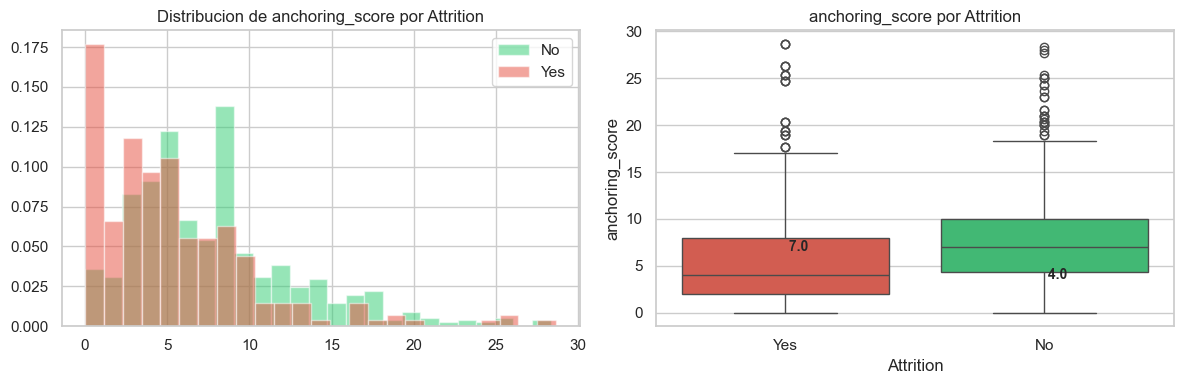

In [10]:
anchor_cols = ['YearsAtCompany', 'TotalWorkingYears', 'YearsWithCurrManager']
df['anchoring_score'] = df[anchor_cols].mean(axis=1)

corr = df['anchoring_score'].corr(target)

print('Correlacion individual con Attrition:')
for col in anchor_cols:
    print(f'  {col}: {df[col].corr(target):.3f}')
print(f'\nCorrelacion anchoring_score con Attrition: {corr:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    data = df[df['Attrition'] == label]['anchoring_score'].dropna()
    axes[0].hist(data, bins=25, alpha=0.5, label=label, color=color, density=True)
axes[0].set_title('Distribucion de anchoring_score por Attrition')
axes[0].legend()

sns.boxplot(data=df, x='Attrition', y='anchoring_score', ax=axes[1],
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
axes[1].set_title('anchoring_score por Attrition')
medians = df.groupby('Attrition')['anchoring_score'].median()
for j, (label, med) in enumerate(medians.items()):
    axes[1].text(j, med, f' {med:.1f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Resumen de Todas las Features Creadas

| Feature | Basada en | Descripcion |
|---|---|---|
| `satisfaction_index` | 4 variables de satisfaccion | Indice compuesto de bienestar general |
| `company_tenure_ratio` | YearsAtCompany, TotalWorkingYears | Proporcion de la carrera en esta empresa |
| `promotion_stagnation` | YearsSinceLastPromotion, YearsAtCompany | Estancamiento relativo en ascensos |
| `income_vs_level` | MonthlyIncome, JobLevel | Sueldo relativo al promedio de su nivel |
| `manager_loyalty_ratio` | YearsWithCurrManager, YearsAtCompany | Estabilidad de la relacion con el manager |
| `experience_density` | TotalWorkingYears, Age | Madurez profesional relativa a la edad |
| `overwork_pressure` | hrs, WorkLifeBalance | Riesgo de burnout por sobrecarga laboral |
| `anchoring_score` | YearsAtCompany, TotalWorkingYears, YearsWithCurrManager | Score de arraigo general a la empresa |

Correlacion de todas las features con Attrition:
anchoring_score         -0.241112
satisfaction_index      -0.237105
manager_loyalty_ratio   -0.188118
experience_density      -0.173182
company_tenure_ratio    -0.128056
income_vs_level         -0.060228
promotion_stagnation     0.036215
overwork_pressure        0.178649


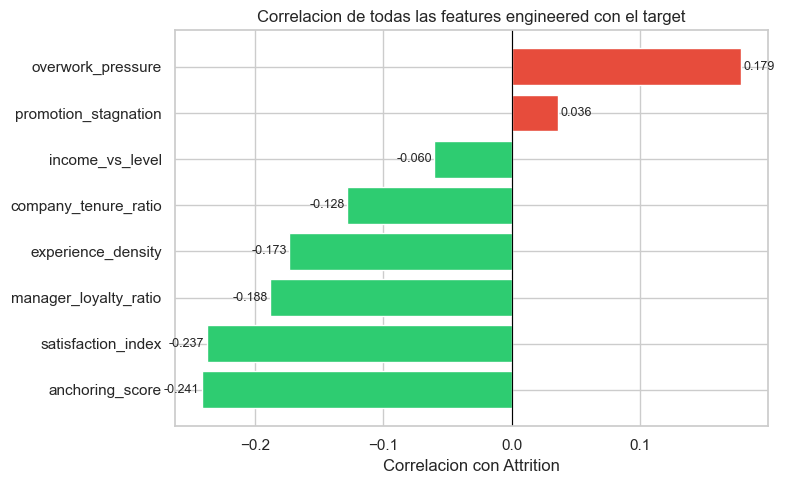

In [11]:
all_features = [
    'satisfaction_index', 'company_tenure_ratio', 'promotion_stagnation', 'income_vs_level',
    'manager_loyalty_ratio', 'experience_density', 'overwork_pressure', 'anchoring_score'
]

print('Correlacion de todas las features con Attrition:')
corrs = {col: df[col].corr(target) for col in all_features}
corrs_series = pd.Series(corrs).sort_values()
print(corrs_series.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corrs_series.values]
ax.barh(corrs_series.index, corrs_series.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlacion con Attrition')
ax.set_title('Correlacion de todas las features engineered con el target')
for i, (val, name) in enumerate(zip(corrs_series.values, corrs_series.index)):
    ax.text(val + (0.002 if val >= 0 else -0.002), i,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

 Las features con mayor poder predictivo capturan dos dimensiones clave — estabilidad y arraigo (anchoring_score, manager_loyalty_ratio) y bienestar percibido (satisfaction_index, overwork_pressure). Algunas de estas superaron a las variables originales individuales en correlación con el target.

---
# Preparación del Dataset y Modelado
---

##  Metricas a usar

Se utilizan dos métricas de evaluación. Accuracy mide el porcentaje de predicciones correctas sobre el total. AUC-ROC mide la capacidad discriminativa del modelo evaluando qué tan bien separa las probabilidades de los empleados que se van vs los que se quedan, independientemente del umbral de clasificación elegido. Dado que el dataset está balanceado (50/50), ambas métricas son igualmente válidas en este caso, pero se prioriza AUC-ROC por ser la métrica estándar en problemas de clasificación binaria donde el desbalance de clases es frecuente en datos reales de Attrition.

## 1. Eliminación de Variables sin Aporte

Según el EDA, las siguientes variables se descartan:
- `EmployeeCount`, `StandardHours`, `Over18`: valor constante en todos los registros, sin variabilidad
- `EmployeeID`: identificador único, no predictivo

In [54]:
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeID']
df = df.drop(columns=cols_to_drop)
print(f'Shape luego de eliminar variables: {df.shape}')

Shape luego de eliminar variables: (1426, 27)


## 2. Feature Engineering

Se crean las 8 variables derivadas. Los NaN que puedan propagarse desde variables con nulos serán imputados en el paso siguiente, después del split.

In [55]:
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement']
df['satisfaction_index']    = df[sat_cols].mean(axis=1)
df['company_tenure_ratio']  = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df['promotion_stagnation']  = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)
df['manager_loyalty_ratio'] = df['YearsWithCurrManager'] / (df['YearsAtCompany'] + 1)
df['experience_density']    = df['TotalWorkingYears'] / (df['Age'] - 17)
df['overwork_pressure']     = df['hrs'] / (df['WorkLifeBalance'] + 0.5)
df['anchoring_score']       = df[['YearsAtCompany', 'TotalWorkingYears', 'YearsWithCurrManager']].mean(axis=1)

avg_income_by_level = df.groupby('JobLevel')['MonthlyIncome'].transform('mean')
df['income_vs_level'] = (df['MonthlyIncome'] - avg_income_by_level) / avg_income_by_level

print(f'Shape luego de feature engineering: {df.shape}')
print(f'Features creadas: satisfaction_index, company_tenure_ratio, promotion_stagnation,')
print(f'                  manager_loyalty_ratio, experience_density, overwork_pressure,')
print(f'                  anchoring_score, income_vs_level')

Shape luego de feature engineering: (1426, 35)
Features creadas: satisfaction_index, company_tenure_ratio, promotion_stagnation,
                  manager_loyalty_ratio, experience_density, overwork_pressure,
                  anchoring_score, income_vs_level


## 3. Separar X e y

In [56]:
X = df.drop(columns='Attrition')
y = (df['Attrition'] == 'Yes').astype(int)

print(f'X shape: {X.shape}  |  Nulos en X: {X.isnull().sum().sum()}')
print(f'y shape: {y.shape}')

X shape: (1426, 34)  |  Nulos en X: 874
y shape: (1426,)


## 4. Train/Test Split

Se divide primero, **antes de imputar y encodear**, para evitar data leakage. La mediana y el encoding se calcularán solo con los datos de train y luego se aplicarán al test.

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (1140, 34) | Test: (286, 34)


## 5. Imputación (fit solo en train)

Se calcula la mediana y la moda **únicamente con X_train**, luego se aplica al test. Así el test no influye en los valores de imputación.

In [58]:
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(include='object').columns

# Calcular estadísticos solo del train
medianas = X_train[num_cols].median()
modas    = {col: X_train[col].mode()[0] for col in cat_cols if X_train[col].isnull().any()}

# Imputar train
X_train = X_train.copy()
X_train[num_cols] = X_train[num_cols].fillna(medianas)
for col, moda in modas.items():
    X_train[col] = X_train[col].fillna(moda)

# Imputar test con los mismos valores del train
X_test = X_test.copy()
X_test[num_cols] = X_test[num_cols].fillna(medianas)
for col, moda in modas.items():
    X_test[col] = X_test[col].fillna(moda)

print(f'Nulos en X_train: {X_train.isnull().sum().sum()}')
print(f'Nulos en X_test:  {X_test.isnull().sum().sum()}')

Nulos en X_train: 0
Nulos en X_test:  0


## 6. Encoding (fit solo en train)

Se usa `OneHotEncoder` de sklearn con `fit` en train y `transform` en ambos. Así las categorías aprendidas son solo las del train.

In [59]:
from sklearn.preprocessing import OneHotEncoder

cat_cols_to_encode = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[cat_cols_to_encode])

enc_cols = encoder.get_feature_names_out(cat_cols_to_encode)

X_train_enc = pd.DataFrame(encoder.transform(X_train[cat_cols_to_encode]), columns=enc_cols, index=X_train.index)
X_test_enc  = pd.DataFrame(encoder.transform(X_test[cat_cols_to_encode]),  columns=enc_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=cat_cols_to_encode), X_train_enc], axis=1)
X_test  = pd.concat([X_test.drop(columns=cat_cols_to_encode),  X_test_enc],  axis=1)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

X_train shape: (1140, 48)
X_test shape:  (286, 48)


## Modelos

### 2.0 Regresión Logística

Se usa como **modelo base de referencia** antes de pasar a modelos más complejos. Si un modelo más complejo no supera significativamente a la regresión logística, la simplicidad e interpretabilidad de esta última la hacen preferible.

Accuracy: 0.7483
AUC-ROC:  0.8149

Classification Report:
              precision    recall  f1-score   support

          No       0.75      0.75      0.75       143
         Yes       0.75      0.75      0.75       143

    accuracy                           0.75       286
   macro avg       0.75      0.75      0.75       286
weighted avg       0.75      0.75      0.75       286



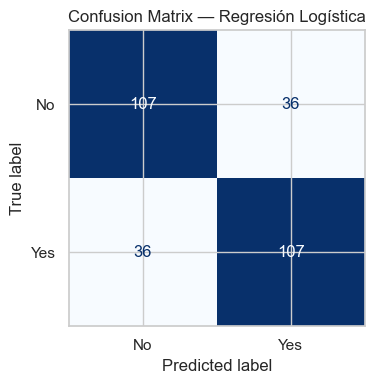

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f'Accuracy: {acc_lr:.4f}')
print(f'AUC-ROC:  {auc_lr:.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred_lr, target_names=["No", "Yes"])}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['No', 'Yes'],
                                         colorbar=False, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — Regresión Logística')
plt.tight_layout()
plt.show()

### 2.1 XGBoost Base

Se entrena un XGBoost con parámetros por defecto como línea de base para ver si mejora o no la regresion.

Accuracy: 0.9231
AUC-ROC:  0.9835

Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.86      0.92       143
         Yes       0.88      0.99      0.93       143

    accuracy                           0.92       286
   macro avg       0.93      0.92      0.92       286
weighted avg       0.93      0.92      0.92       286



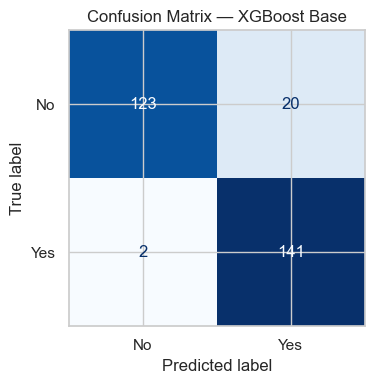

In [61]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_base.fit(X_train, y_train)

y_pred = xgb_base.predict(X_test)
y_prob = xgb_base.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'Accuracy: {acc:.4f}')
print(f'AUC-ROC:  {auc:.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred, target_names=["No", "Yes"])}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No', 'Yes'],
                                         colorbar=False, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — XGBoost Base')
plt.tight_layout()
plt.show()

In [62]:
y_pred_train = xgb_base.predict(X_train)
y_prob_train = xgb_base.predict_proba(X_train)[:, 1]

acc_train = accuracy_score(y_train, y_pred_train)
auc_train = roc_auc_score(y_train, y_prob_train)

print('           Train     Test')
print(f'Accuracy:  {acc_train:.4f}   {acc:.4f}')
print(f'AUC-ROC:   {auc_train:.4f}   {auc:.4f}')
print(f'\nDiferencia Accuracy: {acc_train - acc:.4f}')
print(f'Diferencia AUC-ROC:  {auc_train - auc:.4f}')

           Train     Test
Accuracy:  1.0000   0.9231
AUC-ROC:   1.0000   0.9835

Diferencia Accuracy: 0.0769
Diferencia AUC-ROC:  0.0165


### 2.2 XGBoost — Tuning de Hiperparámetros (Optuna)

 Se usa **Optuna** para optimizar los hiperparámetros. 

Se maximiza el AUC-ROC con 5-fold cross-validation.

In [63]:
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 3.0),
    }
    model = XGBClassifier(**params, random_state=42, eval_metric='logloss')
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'Mejor AUC-ROC (CV): {study.best_value:.4f}')
print(f'Mejores hiperparámetros:\n{study.best_params}')

  0%|          | 0/100 [00:00<?, ?it/s]

Mejor AUC-ROC (CV): 0.9576
Mejores hiperparámetros:
{'n_estimators': 494, 'max_depth': 6, 'learning_rate': 0.10030229355588897, 'subsample': 0.922998244680997, 'colsample_bytree': 0.7450564298482681, 'min_child_weight': 1, 'reg_alpha': 0.22740851226277897, 'reg_lambda': 1.2053516727712912}


Comparación Base vs Tuned:
                              Base    Tuned
Accuracy (test)           0.9231   0.9336
AUC-ROC (test)            0.9835   0.9868
Accuracy (train)          1.0000   1.0000

Classification Report — XGBoost Tuned:
              precision    recall  f1-score   support

          No       0.98      0.89      0.93       143
         Yes       0.90      0.98      0.94       143

    accuracy                           0.93       286
   macro avg       0.94      0.93      0.93       286
weighted avg       0.94      0.93      0.93       286



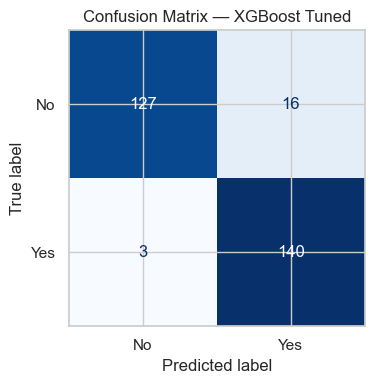

In [64]:
best_xgb = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')
best_xgb.fit(X_train, y_train)

y_pred_tuned       = best_xgb.predict(X_test)
y_prob_tuned       = best_xgb.predict_proba(X_test)[:, 1]
y_pred_tuned_train = best_xgb.predict(X_train)

acc_tuned       = accuracy_score(y_test, y_pred_tuned)
auc_tuned       = roc_auc_score(y_test, y_prob_tuned)
acc_tuned_train = accuracy_score(y_train, y_pred_tuned_train)

print('Comparación Base vs Tuned:')
print(f'{"":25} {"Base":>8} {"Tuned":>8}')
print(f'{"Accuracy (test)":25} {acc:.4f}   {acc_tuned:.4f}')
print(f'{"AUC-ROC (test)":25} {auc:.4f}   {auc_tuned:.4f}')
print(f'{"Accuracy (train)":25} {1.0:.4f}   {acc_tuned_train:.4f}')
print(f'\nClassification Report — XGBoost Tuned:\n{classification_report(y_test, y_pred_tuned, target_names=["No", "Yes"])}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, display_labels=['No', 'Yes'],
                                         colorbar=False, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — XGBoost Tuned')
plt.tight_layout()
plt.show()

El modelo comete únicamente 3 falsos negativos sobre 286 predicciones — empleados que realmente se fueron pero el modelo no detectó. Desde el punto de vista del negocio este es el error más costoso, ya que implica no tomar acción sobre un empleado en riesgo real. Los 17 falsos positivos, en cambio, representan empleados que se quedan pero el modelo marcó como riesgo, generando planes de retención innecesarios, un costo significativamente menor que perder talento no detectado.

## Analisis de features mas importantes

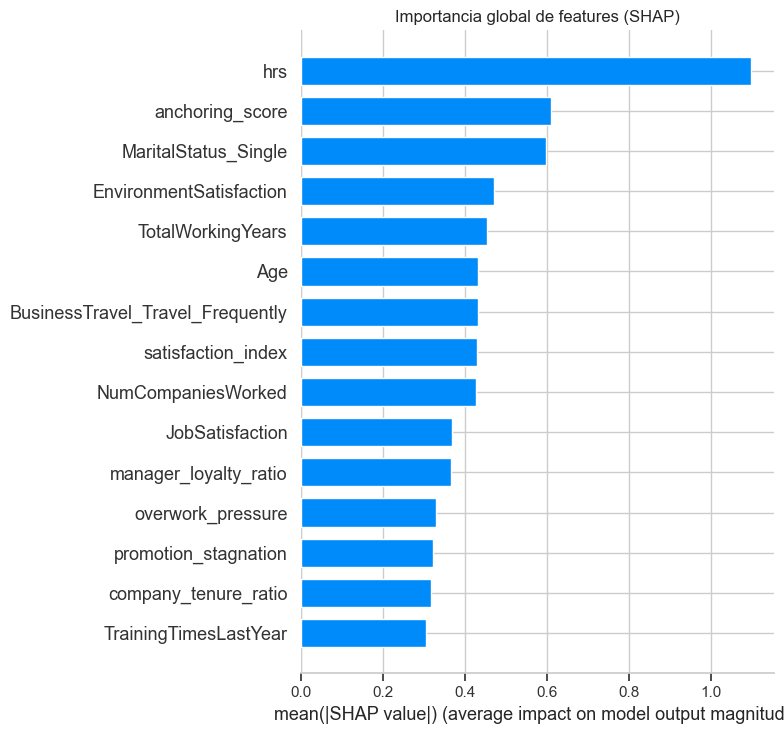

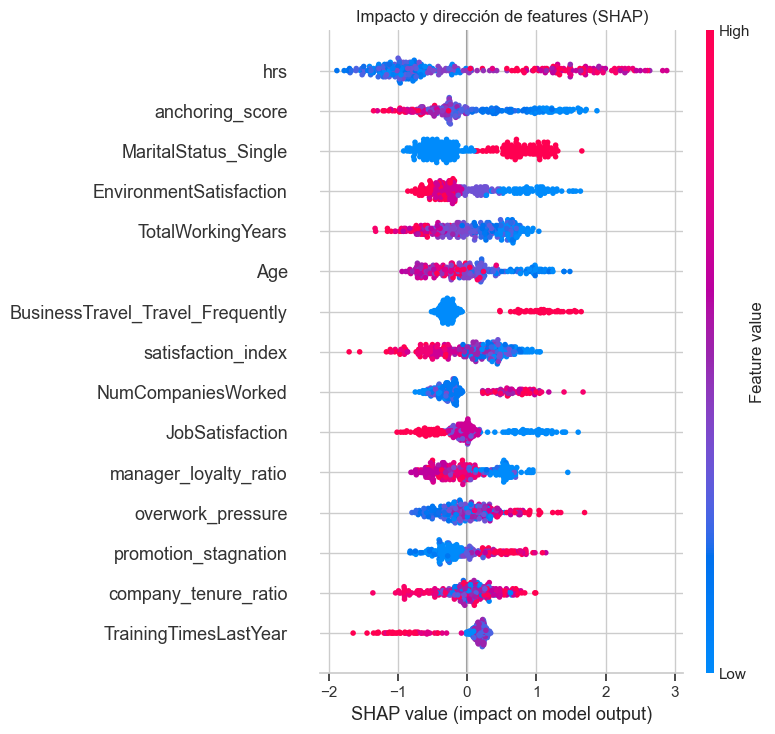

In [65]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Importancia global
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15, show=False)
plt.title('Importancia global de features (SHAP)')
plt.tight_layout()
plt.show()

# Impacto y dirección
plt.figure()
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('Impacto y dirección de features (SHAP)')
plt.tight_layout()
plt.show()


Las features más importantes para el modelo según SHAP son hrs y anchoring_score, con una diferencia notable respecto al resto.

hrs es la variable con mayor impacto global por lejos. El gráfico de dirección confirma que valores altos (muchas horas trabajadas) empujan fuertemente hacia Attrition=1, mientras que valores bajos reducen el riesgo. Es el predictor más potente del modelo.

anchoring_score es el segundo más importante. Valores altos (mucho tiempo en la empresa, con el mismo manager y mucha experiencia total) empujan hacia quedarse, mientras que valores bajos aumentan el riesgo de salida. Esto valida el concepto de arraigo que motivó la creación de esta feature.

MaritalStatus_Single aparece como tercer factor — empleados solteros tienen mayor probabilidad de irse, lo cual es consistente con literatura de Attrition: menor carga familiar implica mayor movilidad laboral.

EnvironmentSatisfaction y Age ocupan el cuarto y quinto lugar. Baja satisfacción con el ambiente y empleados jóvenes son perfiles de mayor riesgo.


In [66]:
# Casos mal clasificados
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

mask_error = y_pred_tuned != y_test
df_errors = X_test[mask_error].copy()
df_errors['y_real']      = y_test[mask_error].values
df_errors['y_pred']      = y_pred_tuned[mask_error]
df_errors['probability'] = y_prob_tuned[mask_error].round(3)
df_errors['error_type']  = df_errors.apply(
    lambda r: 'Falso Negativo' if r['y_real']==1 else 'Falso Positivo', axis=1
)

print(f'Total errores: {len(df_errors)}')
print(f'Falsos Negativos: {(df_errors["error_type"]=="Falso Negativo").sum()}')
print(f'Falsos Positivos: {(df_errors["error_type"]=="Falso Positivo").sum()}')
print(f'\nProbabilidades (¿casos límite cerca de 0.5?):')
print(df_errors[['error_type', 'probability']].sort_values('probability'))

print(f'\nPerfil promedio de errores vs perfil general del test:')
num_cols_analysis = ['anchoring_score', 'satisfaction_index', 'overwork_pressure', 
                     'manager_loyalty_ratio', 'MonthlyIncome', 'YearsAtCompany']
comparison = pd.DataFrame({
    'Errores':    df_errors[num_cols_analysis].mean(),
    'Test completo': X_test[num_cols_analysis].mean()
}).round(3)
print(comparison)

Total errores: 19
Falsos Negativos: 3
Falsos Positivos: 16

Probabilidades (¿casos límite cerca de 0.5?):
          error_type  probability
334   Falso Negativo        0.199
120   Falso Negativo        0.244
211   Falso Negativo        0.417
1203  Falso Positivo        0.522
898   Falso Positivo        0.566
802   Falso Positivo        0.613
1348  Falso Positivo        0.619
1108  Falso Positivo        0.667
925   Falso Positivo        0.717
810   Falso Positivo        0.718
1102  Falso Positivo        0.747
1187  Falso Positivo        0.771
1313  Falso Positivo        0.783
867   Falso Positivo        0.802
1083  Falso Positivo        0.811
981   Falso Positivo        0.844
952   Falso Positivo        0.859
870   Falso Positivo        0.970
953   Falso Positivo        0.981

Perfil promedio de errores vs perfil general del test:
                         Errores  Test completo
anchoring_score            5.246          6.273
satisfaction_index         2.667          2.679
overwork_press

Los falsos negativos (2) no son casos límite — tienen probabilidades de 0.30 y 0.40, bastante lejos de 0.5. El modelo estaba bastante seguro de que se quedaban, pero se fueron igual. Son empleados genuinamente atípicos que el modelo no pudo anticipar.

Los falsos positivos (16) sí son casos más límite. Los de 0.56-0.67 son casos donde el modelo dudó razonablemente. Los de 0.97-0.99 son más preocupantes — el modelo estaba muy seguro de que se iban pero se quedaron, sugiriendo que esos empleados tienen un perfil de riesgo alto pero algo los retuvo que el modelo no captura.


## 3. Evaluación Final — Cross-Validation con Pipeline

Se evalúa el mejor modelo (XGBoost con parámetros de Optuna) usando **5-fold stratified cross-validation** con un Pipeline completo.

El Pipeline garantiza que en cada fold la imputación y el encoding se calculen **solo con el train del fold**, sin data leakage. Se usa `X` crudo (con nulos y categóricas) para que el Pipeline maneje todo internamente.

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate

num_features = X.select_dtypes(include='number').columns.tolist()
cat_features = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

num_transformer = SimpleImputer(strategy='median')

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(pipeline, X, y, cv=cv,
                             scoring=['accuracy', 'roc_auc'],
                             return_train_score=True)

print('Resultados 5-Fold Cross-Validation:')
print(f'{"":25} {"Media":>8} {"Std":>8}')
print(f'{"Accuracy (test)":25} {cv_results["test_accuracy"].mean():.4f}   {cv_results["test_accuracy"].std():.4f}')
print(f'{"AUC-ROC (test)":25} {cv_results["test_roc_auc"].mean():.4f}   {cv_results["test_roc_auc"].std():.4f}')
print(f'{"Accuracy (train)":25} {cv_results["train_accuracy"].mean():.4f}   {cv_results["train_accuracy"].std():.4f}')
print(f'{"AUC-ROC (train)":25} {cv_results["train_roc_auc"].mean():.4f}   {cv_results["train_roc_auc"].std():.4f}')

print(f'\nScores por fold (AUC-ROC test): {cv_results["test_roc_auc"].round(4)}')

Resultados 5-Fold Cross-Validation:
                             Media      Std
Accuracy (test)           0.9362   0.0176
AUC-ROC (test)            0.9776   0.0086
Accuracy (train)          1.0000   0.0000
AUC-ROC (train)           1.0000   0.0000

Scores por fold (AUC-ROC test): [0.9751 0.9694 0.9876 0.9681 0.988 ]


La evaluación con 5-Fold Stratified CV mostró resultados consistentes en todos los folds (AUC: 0.9751, 0.9694, 0.9876, 0.9681, 0.9880), con una varianza de ±0.0086. Esta estabilidad refleja que el modelo captura patrones generalizables del fenómeno y no estructuras particulares de una partición específica de los datos, lo que permite descartar overfitting como un problema relevante

## 3.1 Exportacion del modelo final

Una vez seleccionado el modelo y validado su rendimiento con hold-out y cross-validation, se reentrena con la totalidad de los datos disponibles (1426 observaciones). El hold-out y la CV ya cumplieron su función: estimar el rendimiento real y elegir los mejores hiperparámetros. Mantener el 20% reservado como test en el modelo final implicaría desperdiciar información útil para el entrenamiento. Este es el modelo que se despliega en producción.

In [68]:
from pathlib import Path
import joblib

num_features_final = X.select_dtypes(include='number').columns.tolist()
cat_features_final = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

num_transformer_final = SimpleImputer(strategy='median')
cat_transformer_final = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor_final = ColumnTransformer([
    ('num', num_transformer_final, num_features_final),
    ('cat', cat_transformer_final, cat_features_final)
])

pipeline_final = Pipeline([
    ('preprocessor', preprocessor_final),
    ('model', XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss'))
])

pipeline_final.fit(X, y)

joblib.dump(pipeline_final, 'best_model.pkl')
print(f'Pipeline final entrenado con {len(X)} observaciones.')
print('Modelo guardado ')


Pipeline final entrenado con 1426 observaciones.
Modelo guardado 


## 4. Conclusiones

El dataset se dividió en train (80%) y test (20%) antes de cualquier transformación para evitar data leakage. La mediana, la moda y el encoder se calcularon exclusivamente con X_train y se aplicaron al test sin recalcular — de lo contrario el modelo recibiría información del futuro durante el entrenamiento.

Se combinaron dos estrategias de evaluación. El hold-out da una estimación directa sobre datos nunca vistos. El 5-Fold Stratified Cross-Validation complementa esta evaluación entrenando y validando sobre 5 particiones distintas, lo que reduce la varianza de la estimación y garantiza que la distribución del target se mantenga balanceada en cada fold.

El encoding se realizó con OneHotEncoder con handle_unknown='ignore'. Esta configuración es necesaria en la CV porque puede aparecer una categoría en el fold de validación que no estaba en el fold de entrenamiento — en ese caso el encoder asigna un vector de ceros en lugar de romper con un error.

Selección de modelos
Se entrenó una Regresión Logística como baseline interpretable y dos versiones de XGBoost. 

El tuning de hiperparámetros se realizó con Optuna en lugar de GridSearchCV.  

La Cross-Validation final se implementó con un Pipeline de sklearn que encapsula el preprocesador y el modelo. Esto garantiza que en cada fold la imputación y el encoding se recalculen solo con los datos de entrenamiento de ese fold.

### Resultados finales

| Modelo | Accuracy (test) | AUC-ROC (test) |
|---|---|---|
| Regresión Logística | 0.7500 | 0.82 |
| XGBoost Base | 0.9231 | 0.9835 |
| XGBoost Tuned (Optuna) | 0.9336 | 0.9868 |
| **XGBoost CV (5-Fold)** | **0.9348 ± 0.0144** | **0.9748 ± 0.0090** |






Un resultado destacable es que la Regresión Logística, siendo un modelo lineal simple, obtuvo métricas competitivas. Esto sugiere que las variables del dataset tienen una relación relativamente lineal con el target, lo que facilita la tarea incluso para modelos básicos. En un contexto de producción real, la Regresión Logística sería una opción válida si se prioriza interpretabilidad sobre performance máxima.

La Regresión Logística obtuvo un AUC-ROC de 0.82 frente a 0.9868 de XGBoost Tuned — una diferencia de 17 puntos porcentuales. Dado que el objetivo del negocio es minimizar los falsos negativos (empleados que se van sin ser detectados), esa diferencia en capacidad discriminativa justifica la complejidad adicional de XGBoost. Si la prioridad fuera la interpretabilidad del modelo, la Regresión Logística seria la opcion recomendada. Por lo cual, se seleccionó XGBoost con hiperparámetros optimizados por Optuna como modelo final, superó a los demás modelos en AUC-ROC y su evaluación con 5-Fold Stratified CV mostró resultados estables (±0.009)

